# 1. Verifica della Qualità (Data Cleaning)
- Cercare valori mancanti (NaN)
- Usare `.info()` e `.describe()` di pandas

In [16]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Copper HG=F
tiker_copper_symbol = "HG=F"
# Create a ticker object
ticker_copper = yf.Ticker(tiker_copper_symbol)
# data for the last year
coppere_data = ticker_copper.history(period="1y")
print("--- DATA HEAD ---")
print(coppere_data.head())
print("\n--- DATA INFO ---")
print(coppere_data.info())
print("\n--- DATA DESCRIBE ---")
print(coppere_data.describe())

--- DATA HEAD ---
                             Open    High     Low   Close  Volume  Dividends  \
Date                                                                           
2025-03-03 00:00:00-05:00  4.5445  4.6160  4.5080  4.5765    1408        0.0   
2025-03-04 00:00:00-05:00  4.5660  4.5670  4.5000  4.5275    1394        0.0   
2025-03-05 00:00:00-05:00  4.5350  4.7900  4.5350  4.7665     819        0.0   
2025-03-06 00:00:00-05:00  4.7815  4.8025  4.7225  4.7790    1108        0.0   
2025-03-07 00:00:00-05:00  4.7520  4.7560  4.6570  4.6830     903        0.0   

                           Stock Splits  
Date                                     
2025-03-03 00:00:00-05:00           0.0  
2025-03-04 00:00:00-05:00           0.0  
2025-03-05 00:00:00-05:00           0.0  
2025-03-06 00:00:00-05:00           0.0  
2025-03-07 00:00:00-05:00           0.0  

--- DATA INFO ---
<class 'pandas.DataFrame'>
DatetimeIndex: 252 entries, 2025-03-03 00:00:00-05:00 to 2026-03-02 00:00:00-05:0

---

## Multi asset analysis

In [3]:
# Download multi asset data
assets = ["HG=F", "DX-Y.NYB", "CL=F"]
raw_data = yf.download(assets, period="1y")

[*********************100%***********************]  3 of 3 completed


In [ ]:
raw_data.head()
raw_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 253 entries, 2025-03-03 to 2026-03-02
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, CL=F)       252 non-null    float64
 1   (Close, DX-Y.NYB)   252 non-null    float64
 2   (Close, HG=F)       252 non-null    float64
 3   (High, CL=F)        252 non-null    float64
 4   (High, DX-Y.NYB)    252 non-null    float64
 5   (High, HG=F)        252 non-null    float64
 6   (Low, CL=F)         252 non-null    float64
 7   (Low, DX-Y.NYB)     252 non-null    float64
 8   (Low, HG=F)         252 non-null    float64
 9   (Open, CL=F)        252 non-null    float64
 10  (Open, DX-Y.NYB)    252 non-null    float64
 11  (Open, HG=F)        252 non-null    float64
 12  (Volume, CL=F)      252 non-null    float64
 13  (Volume, DX-Y.NYB)  252 non-null    float64
 14  (Volume, HG=F)      252 non-null    float64
dtypes: float64(15)
memory usage: 31.6 KB


Price        Close                                High              \
Ticker        CL=F    DX-Y.NYB        HG=F        CL=F    DX-Y.NYB   
count   252.000000  252.000000  252.000000  252.000000  252.000000   
mean     63.039325   99.173167    5.059736   64.054206   99.488306   
std       3.844833    1.962690    0.487197    4.090263    1.994874   
min      55.270000   96.220001    4.127500   56.700001   96.660004   
25%      60.087501   97.867502    4.651500   60.997500   98.187502   
50%      62.740000   98.720001    4.976250   63.820000   98.990002   
75%      65.467497   99.592497    5.440500   66.717499   99.959999   
max      75.139999  106.750000    6.175500   78.400002  107.559998   

Price                      Low                                Open  \
Ticker        HG=F        CL=F    DX-Y.NYB        HG=F        CL=F   
count   252.000000  252.000000  252.000000  252.000000  252.000000   
mean      5.099579   62.077897   98.863087    5.007742   63.107976   
std       0.493968    3.724335    1.918578    0.476522    3.974793   
min       4.153000   54.980000   95.550003    4.098500   55.230000   
25%       4.697750   59.142499   97.629997    4.589750   60.130001   
50%       5.000500   62.059999   98.490002    4.940000   62.855000   
75%       5.482625   64.732500   99.324999    5.345375   65.497498   
max       6.508000   74.300003  106.470001    6.131500   78.000000   

Price                                  Volume                         
Ticker    DX-Y.NYB        HG=F           CL=F DX-Y.NYB          HG=F  
count   252.000000  252.000000     252.000000    252.0    252.000000  
mean     99.198429    5.052121  276382.670635      0.0   1716.746032  
std       2.017172    0.485533  118473.675102      0.0   4529.866418  
min      95.970001    4.141000       0.000000      0.0      0.000000  
25%      97.897501    4.646750  223626.500000      0.0    653.750000  
50%      98.669998    4.964250  267238.500000      0.0    877.500000  
75%      99.642500    5.432250  324298.750000      0.0   1120.250000  
max     107.559998    6.157000  735186.000000      0.0  41937.000000

---

# pulizia dei dati
- Prendo solo i prezzi di chiusura `Close`
- 252/253 righe non-null, `dropna` per eliminare la riga con valore negativo

In [14]:
# create copy, do not to use a view
close_price = raw_data["Close"].copy()
close_price = close_price.dropna()
close_price.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-03 to 2026-03-02
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CL=F      251 non-null    float64
 1   DX-Y.NYB  251 non-null    float64
 2   HG=F      251 non-null    float64
dtypes: float64(3)
memory usage: 7.8 KB


### Risultati
1. Solo prezzi di chiusura
2. 251 righe non-null (Ogni riga avava un `NaN`, ma `non la stessa riga`)

---

## Matrice di correlazione

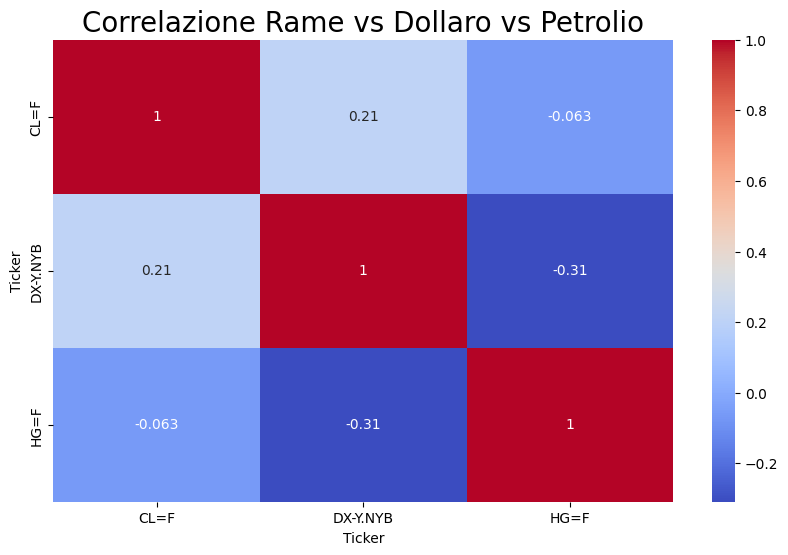

In [25]:
corr_matrix = close_price.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlazione Rame vs Dollaro vs Petrolio", size=20)
plt.show()

### Risultati
Sembra non esserci correlazione
Possibili cause:
- Le materie vengono influenzate successivamente (c'è un lag)
- Le variazioni dei prezzi grezzi non sono significative (devo usare la variazione percentuale)

---

## Variazione percentuale
Calcolo le differenze percentuali *per confrontare mele con mele*

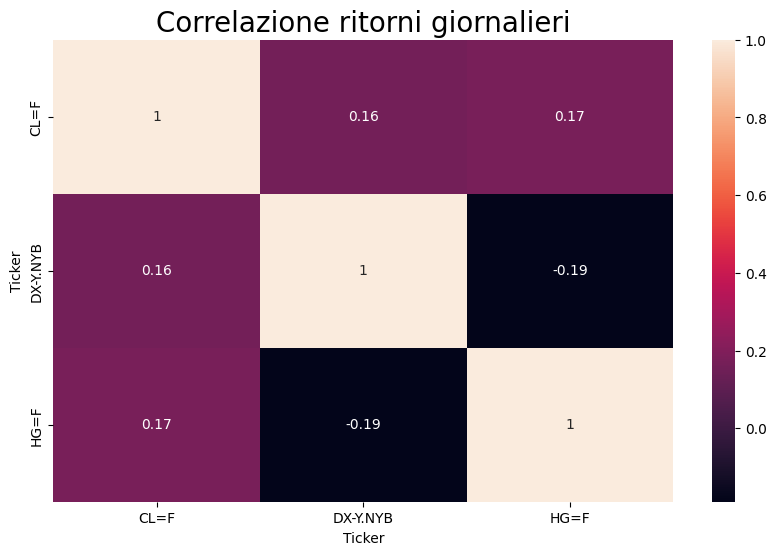

In [28]:
# daily returns
df_returns = close_price.pct_change().dropna()
returns_correlation_matrix = df_returns.corr()
plt.figure(figsize=(10,6))
sns.heatmap(returns_correlation_matrix, annot=True)
plt.title("Correlazione ritorni giornalieri", size=20)
plt.show()

### Results
Correlazioni ancora molto deboli
Possibili cause:
- Lag

---

## I conti non tornano
Vediamo con dei grafici cosa sta succedendo
Con `regoplot` vediamo:
- Scatter plot (punti)
- Regreessione lineare (linea)
- Intervallo di confidenza al 95% (ombra)

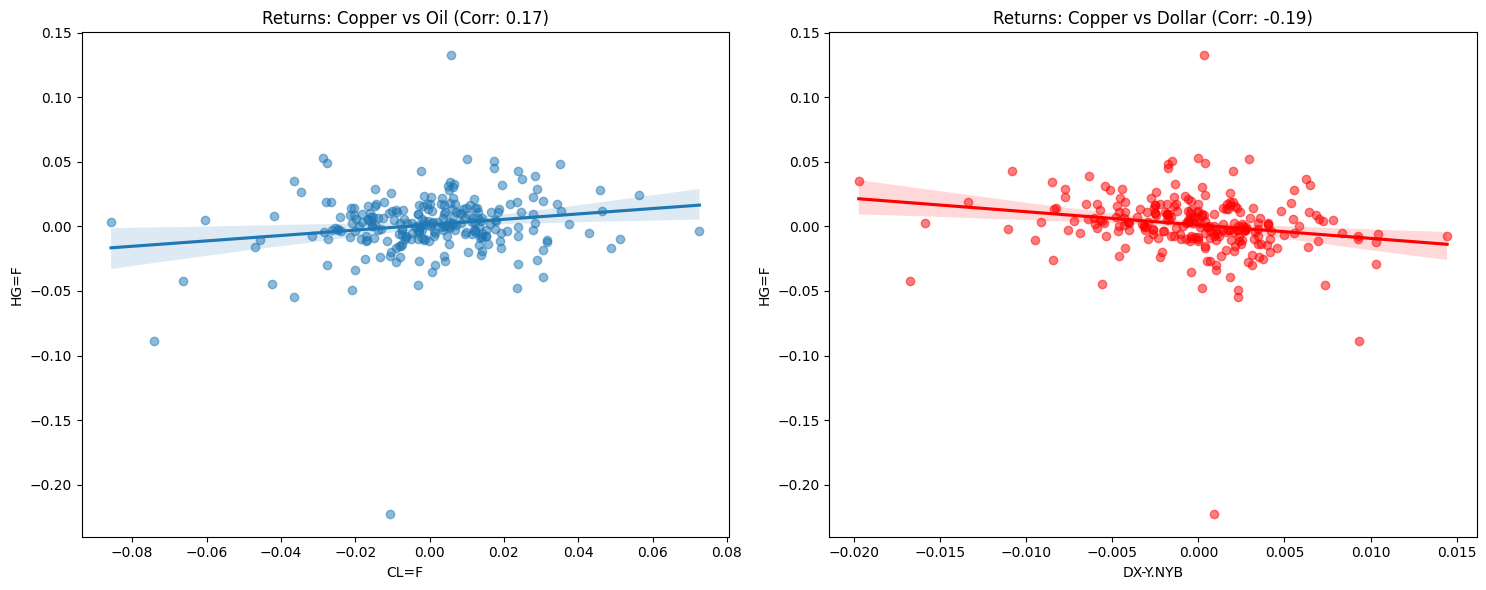

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Rame vs Petrolio
sns.regplot(x=df_returns['CL=F'], y=df_returns['HG=F'], ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title(f'Returns: Copper vs Oil (Corr: {df_returns.corr().iloc[0,2]:.2f})')

# Rame vs Dollaro
sns.regplot(x=df_returns['DX-Y.NYB'], y=df_returns['HG=F'], ax=ax2, scatter_kws={'alpha':0.5}, color='red')
ax2.set_title(f'Returns: Copper vs Dollar (Corr: {df_returns.corr().iloc[1,2]:.2f})')

plt.tight_layout()
plt.show()

## Risultati
1. Il fatto che la nuvola di punti sia dispersa e la linea di `regplot` sia quasi piatta ti dice che il mercato è efficiente.
2. Quei punti lontani dalla linea di regressione sono le anomalie. L'AI dovrà imparare a ignorare questi "botti" estemporanei per concentrarsi sul segnale sottostante.
3. Poiché il Dollaro di oggi non spiega il Rame di oggi, i dati suggeriscono che l'influenza potrebbe essere ritardata.

---